# CIFAR-100 Data Exploration

Standalone Colab notebook for inspecting CIFAR-100 fine labels, coarse superclasses, and the two binary tasks used later in the project.

**Objective.** Confirm the dataset loads from Hugging Face, sanity-check the label maps, and quantify class imbalance for one fine-class task and one superclass task.

**Done when.** Train/test sizes match expectations (50,000 / 10,000), both label maps print, both binary tasks report positive rates, and visual grids render mixed positives and negatives.

**Plan.**
1. Setup: imports, seed, dataset load.
2. Label maps: list fine and coarse names.
3. Binary task helpers: `label_id`, `binary_labels`, `summarize_binary_task`.
4. Fine-class task: `cattle` vs. rest.
5. Superclass task: `aquatic_mammals` vs. rest.
6. Visual spot-check of a small mixed-label grid for each task.

**Convention.** This notebook does not import local project modules under `data/`, `models/`, `training/`, or `evaluation/` so it stays runnable in a fresh Colab.

## Setup

Imports the dataset from Hugging Face (`uoft-cs/cifar100`), seeds NumPy for reproducibility, and installs `datasets` on the fly if it is missing. On a local environment, prefer `pip install -r requirements.txt` instead of the inline install.

In [1]:
# Install `datasets` on demand when running in a fresh Colab.
# Uses subprocess so static type-checkers (Pylance) don't choke on the %pip magic.
try:
    import datasets  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

SEED = 42
rng = np.random.default_rng(SEED)

/Users/fgram-devai/Documents/Projects/Python/deepL-image-analysis/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load CIFAR-100

Hugging Face caches the dataset under `~/.cache/huggingface/datasets/`, so the first load downloads ~170 MB and subsequent runs are instant.

In [2]:
dataset = load_dataset("uoft-cs/cifar100")
dataset

DatasetDict({
    train: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 10000
    })
})

In [3]:
train = dataset["train"]
test = dataset["test"]

fine_names = train.features["fine_label"].names
coarse_names = train.features["coarse_label"].names

assert len(train) == 50_000, len(train)
assert len(test) == 10_000, len(test)
assert len(fine_names) == 100, len(fine_names)
assert len(coarse_names) == 20, len(coarse_names)

print(f"train rows: {len(train):,}")
print(f"test rows:  {len(test):,}")
print(f"fine classes: {len(fine_names)}")
print(f"coarse classes: {len(coarse_names)}")
print(f"image example size: {train[0]['img'].size}")

train rows: 50,000
test rows:  10,000
fine classes: 100
coarse classes: 20
image example size: (32, 32)


## Label Maps

In [4]:
print("First 20 fine labels:")
for i, name in enumerate(fine_names[:20]):
    print(f"{i:02d}: {name}")

print("\nCoarse labels:")
for i, name in enumerate(coarse_names):
    print(f"{i:02d}: {name}")

First 20 fine labels:
00: apple
01: aquarium_fish
02: baby
03: bear
04: beaver
05: bed
06: bee
07: beetle
08: bicycle
09: bottle
10: bowl
11: boy
12: bridge
13: bus
14: butterfly
15: camel
16: can
17: castle
18: caterpillar
19: cattle

Coarse labels:
00: aquatic_mammals
01: fish
02: flowers
03: food_containers
04: fruit_and_vegetables
05: household_electrical_devices
06: household_furniture
07: insects
08: large_carnivores
09: large_man-made_outdoor_things
10: large_natural_outdoor_scenes
11: large_omnivores_and_herbivores
12: medium_mammals
13: non-insect_invertebrates
14: people
15: reptiles
16: small_mammals
17: trees
18: vehicles_1
19: vehicles_2


## Binary Task Helpers

In [5]:
def label_id(label_names, label_name):
    """Return the integer id for a label name."""
    if label_name not in label_names:
        raise ValueError(f"Unknown label: {label_name}")
    return label_names.index(label_name)


def binary_labels(split, label_column, positive_id):
    """Return 0/1 labels for positive_id vs all other ids."""
    labels = np.asarray(split[label_column], dtype=np.int64)
    return (labels == positive_id).astype(np.int64)


def summarize_binary_task(split_name, y):
    """Print class counts and positive rate for a binary task."""
    counts = Counter(y.tolist())
    total = len(y)
    pos = counts.get(1, 0)
    neg = counts.get(0, 0)
    print(
        f"{split_name}: total={total:,} neg={neg:,} pos={pos:,} "
        f"positive_rate={pos / total:.4f}"
    )

## Fine-Class Task: Cattle/Cow vs. Rest

In [6]:
fine_target_name = "cattle"
fine_target_id = label_id(fine_names, fine_target_name)

y_train_fine = binary_labels(train, "fine_label", fine_target_id)
y_test_fine = binary_labels(test, "fine_label", fine_target_id)

print(f"Fine target: {fine_target_name!r}, id={fine_target_id}")
summarize_binary_task("train", y_train_fine)
summarize_binary_task("test", y_test_fine)

Fine target: 'cattle', id=19
train: total=50,000 neg=49,500 pos=500 positive_rate=0.0100
test: total=10,000 neg=9,900 pos=100 positive_rate=0.0100


## Superclass Task: Aquatic Mammals vs. Rest

In [7]:
coarse_target_name = "aquatic_mammals"
coarse_target_id = label_id(coarse_names, coarse_target_name)

y_train_coarse = binary_labels(train, "coarse_label", coarse_target_id)
y_test_coarse = binary_labels(test, "coarse_label", coarse_target_id)

print(f"Coarse target: {coarse_target_name!r}, id={coarse_target_id}")
summarize_binary_task("train", y_train_coarse)
summarize_binary_task("test", y_test_coarse)

Coarse target: 'aquatic_mammals', id=0
train: total=50,000 neg=47,500 pos=2,500 positive_rate=0.0500
test: total=10,000 neg=9,500 pos=500 positive_rate=0.0500


## Visual Check

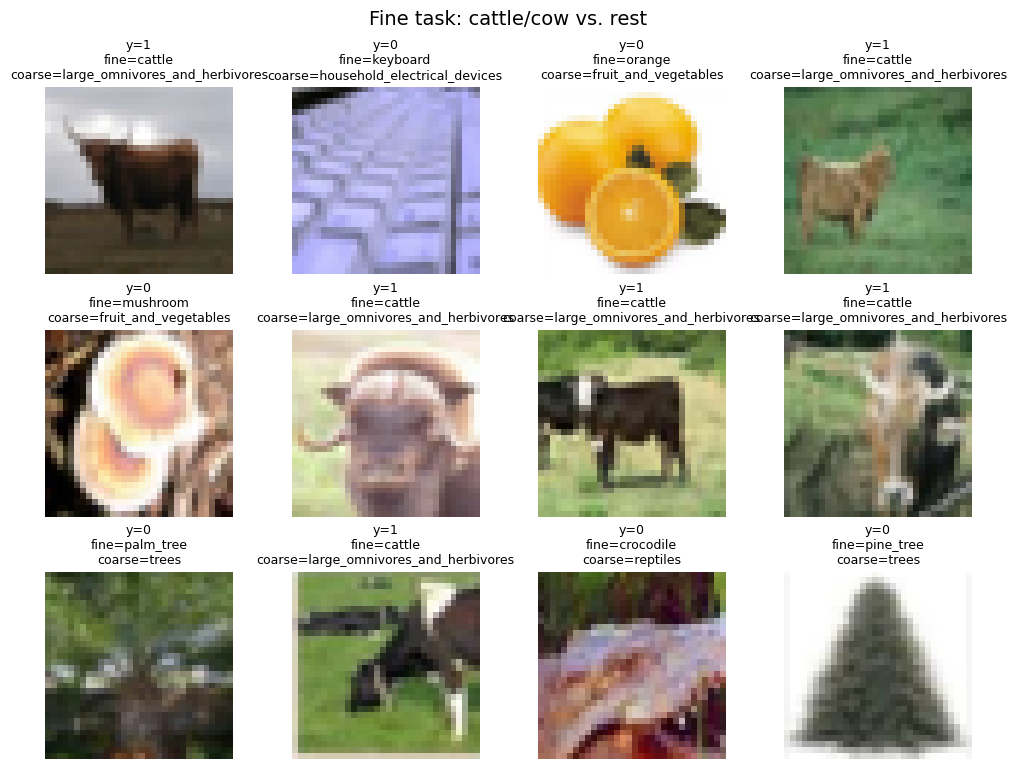

In [8]:
def show_examples(split, binary_y, title, n=12):
    """Show a balanced-ish grid of positive and negative examples."""
    pos_idx = np.flatnonzero(binary_y == 1)
    neg_idx = np.flatnonzero(binary_y == 0)
    n_pos = min(n // 2, len(pos_idx))
    n_neg = n - n_pos
    chosen = np.concatenate([
        rng.choice(pos_idx, size=n_pos, replace=False),
        rng.choice(neg_idx, size=n_neg, replace=False),
    ])
    rng.shuffle(chosen)

    cols = 4
    rows = int(np.ceil(len(chosen) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(10, 2.6 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, idx in zip(axes, chosen):
        row = split[int(idx)]
        ax.imshow(row["img"])
        ax.set_title(
            f"y={int(binary_y[int(idx)])}\n"
            f"fine={fine_names[row['fine_label']]}\n"
            f"coarse={coarse_names[row['coarse_label']]}",
            fontsize=9,
        )
        ax.axis("off")
    for ax in axes[len(chosen):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()


show_examples(train, y_train_fine, "Fine task: cattle/cow vs. rest")

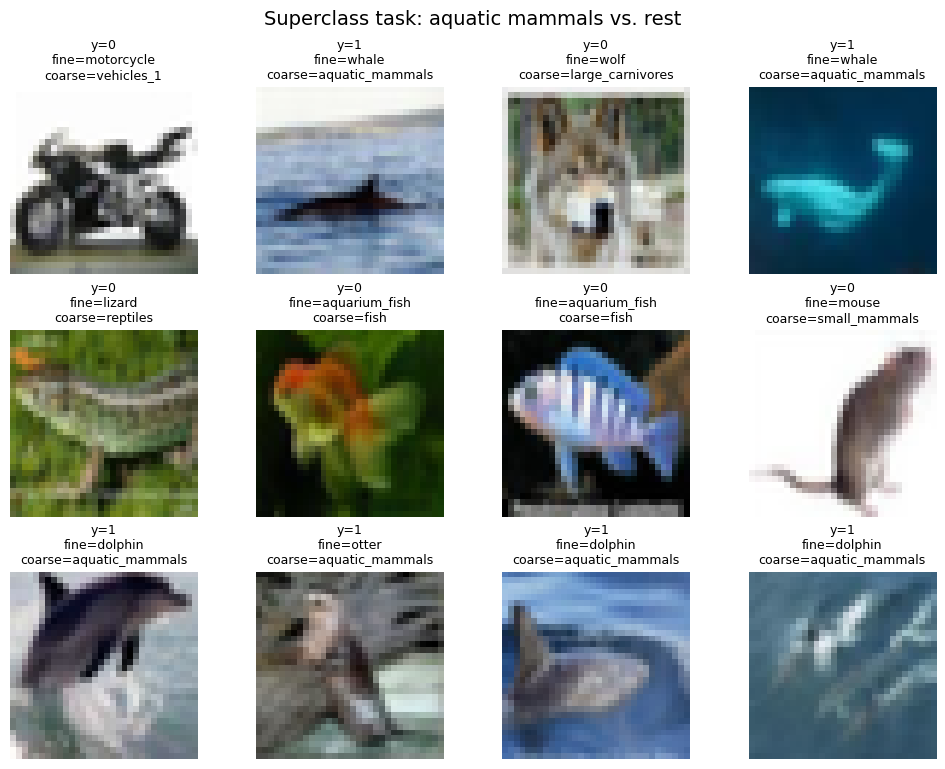

In [9]:
show_examples(train, y_train_coarse, "Superclass task: aquatic mammals vs. rest")

## Notes

- Fine-class target-vs-rest tasks are strongly imbalanced (~1% positive); plan to use class weighting or threshold tuning in the modeling notebooks.
- Superclass target-vs-rest tasks are less imbalanced (~5% positive) and are useful for smoke runs and quick architecture comparisons.
- Later notebooks should keep using standalone definitions rather than importing project modules, so each notebook stays self-contained in Colab.
- Re-running this notebook with `SEED = 42` reproduces the same image grids.